# PCA Trajectory of Word-Flip Attacks in Embedding Space

The text counterpart of `latent_space/PCA_trajectory.ipynb` in the companion vision repo, which
traces how FGSM moves an image's penultimate-layer features across the CNN's latent space as
$\varepsilon$ grows. Here the "attack strength" is discrete, the number of words flipped, but the
idea is identical: extract the sentence embedding right before the final classification layer, fit
PCA on a background cloud of ordinary sentences to get a stable 2D reference frame, then project
the sentence's embedding after each HotFlip step to see whether it visibly drifts from its original
region towards the opposite class's region as more words change.


In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModelForSequenceClassification

### Setup: Model and Sentence Embeddings
`distilbert-base-uncased-finetuned-sst-2-english`, same target as the rest of the repo. Its
classification head is `hidden_state[:, 0] -> pre_classifier -> ReLU -> classifier`, so we treat the
768-dimensional output of `pre_classifier` as the sentence embedding, the exact penultimate-layer
analogue of the CNN feature extractor used in the vision notebook.

In [2]:
MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
LABELS = model.config.id2label
SPECIAL_TOKEN_IDS = set(tokenizer.all_special_ids)
embedding_matrix = model.get_input_embeddings().weight

@torch.no_grad()
def sentence_embedding(text):
    inputs = tokenizer(text, return_tensors='pt')
    hidden_state = model.distilbert(**inputs).last_hidden_state
    pooled = hidden_state[:, 0]
    pooled = torch.relu(model.pre_classifier(pooled))
    return pooled[0].numpy()

@torch.no_grad()
def predict(text):
    inputs = tokenizer(text, return_tensors='pt')
    probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    label_idx = int(torch.argmax(probs))
    return LABELS[label_idx], label_idx

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### Background Cloud
Embed a broad sample of real SST-2 validation sentences and fit PCA on them. This gives a stable
2D reference frame, colored by the model's own prediction, against which the attack trajectories
can be compared: do the flipped sentences actually cross into the other class's region, or just
wander nearby without leaving it?

In [3]:
sst2 = load_dataset('stanfordnlp/sst2', split='validation')
N_BACKGROUND = 150
background_pool = sst2.select(range(N_BACKGROUND))

background_embeddings = np.stack([sentence_embedding(ex['sentence'].strip()) for ex in background_pool])
background_preds = [predict(ex['sentence'].strip())[1] for ex in background_pool]

pca = PCA(n_components=2)
pca.fit(background_embeddings)
background_2d = pca.transform(background_embeddings)
print(f"Explained variance: PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%")

Explained variance: PC1 89.8%, PC2 5.7%


### HotFlip Trajectories
For a handful of example sentences, run HotFlip one flip at a time, embedding the sentence after
every single flip so the intermediate steps are visible, not just the final result.

In [4]:
def hotflip_step(input_ids, true_label_idx):
    embeds = embedding_matrix[input_ids].clone().detach().unsqueeze(0)
    embeds.requires_grad_(True)
    logits = model(inputs_embeds=embeds).logits
    loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
    loss.backward()
    grad = embeds.grad[0]

    best_score, best_pos, best_candidate = float('-inf'), None, None
    for pos in range(len(input_ids)):
        if input_ids[pos].item() in SPECIAL_TOKEN_IDS:
            continue
        current_embed = embedding_matrix[input_ids[pos]]
        scores = (embedding_matrix - current_embed) @ grad[pos]
        candidate_id = int(torch.argmax(scores))
        if scores[candidate_id] > best_score:
            best_score = float(scores[candidate_id])
            best_pos, best_candidate = pos, candidate_id
    return best_pos, best_candidate

def hotflip_trajectory(text, max_flips=6):
    input_ids = tokenizer(text, return_tensors='pt')['input_ids'][0]
    _, true_label_idx = predict(text)
    texts = [text]
    for _ in range(max_flips):
        pos, candidate_id = hotflip_step(input_ids, true_label_idx)
        input_ids = input_ids.clone()
        input_ids[pos] = candidate_id
        adv_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        texts.append(adv_text)
        if predict(adv_text)[1] != true_label_idx:
            break
    return texts

In [5]:
SAMPLE_REVIEWS = [
    "This movie was absolutely fantastic, I loved every minute of it.",
    "The acting was terrible and the plot made no sense at all.",
    "A brilliant, moving performance that will stay with me for years.",
]

trajectories = {}
for review in SAMPLE_REVIEWS:
    texts = hotflip_trajectory(review, max_flips=6)
    embeddings_2d = pca.transform(np.stack([sentence_embedding(t) for t in texts]))
    trajectories[review] = embeddings_2d
    print(f"{review[:50]}... -> {len(texts) - 1} flips, final: {predict(texts[-1])[0]}")

C:\Users\frang\AppData\Local\Temp\ipykernel_23192\3194961727.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  best_score = float(scores[candidate_id])


This movie was absolutely fantastic, I loved every... -> 2 flips, final: NEGATIVE


The acting was terrible and the plot made no sense... -> 3 flips, final: POSITIVE


A brilliant, moving performance that will stay wit... -> 2 flips, final: NEGATIVE


### Plot: Background Regions and Attack Trajectories
The background cloud shows where ordinary positive and negative sentences sit in this 2D
projection; each trajectory starts at a star (the original sentence) and moves through one point
per flip, color-graded from light to dark as more words change.

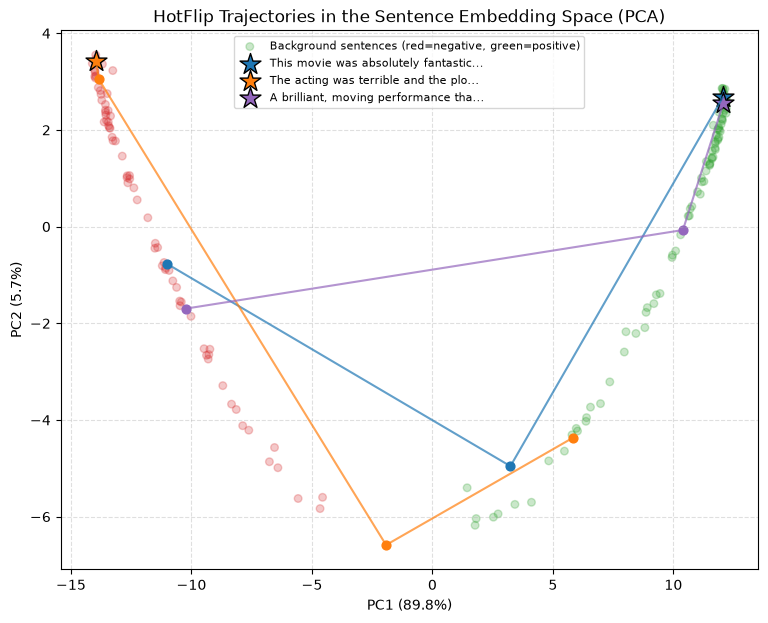

In [6]:
plt.figure(figsize=(9, 7))

colors = ['tab:red' if p == 0 else 'tab:green' for p in background_preds]
plt.scatter(background_2d[:, 0], background_2d[:, 1], c=colors, alpha=0.25, s=30,
            label='Background sentences (red=negative, green=positive)')

trajectory_colors = ['tab:blue', 'tab:orange', 'tab:purple']
for (review, points), color in zip(trajectories.items(), trajectory_colors):
    plt.plot(points[:, 0], points[:, 1], '-', color=color, alpha=0.7)
    plt.scatter(points[1:, 0], points[1:, 1], c=color, s=40)
    plt.scatter(points[0, 0], points[0, 1], c=color, marker='*', s=250,
                edgecolors='black', label=review[:35] + '...')

plt.title('HotFlip Trajectories in the Sentence Embedding Space (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(fontsize=8, loc='best')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()